# Read Results

In [1]:
#We use pickle to store intermediate results, ensuring reproducibility and 
# allowing future experiments to skip data preparation and unimodal encoder processing.
import pickle

with open("cache/dpf_mvsa_single_results.pkl", "rb") as f:
    results = pickle.load(f)

# RETRIEVE  Varibles from results
train_probs_text   = results["train_probs_text"]
train_probs_image  = results["train_probs_image"]

val_probs_text     = results["val_probs_text"]
val_probs_image    = results["val_probs_image"]

test_probs_text    = results["test_probs_text"]
test_probs_image   = results["test_probs_image"]

y_train_int = results["y_train_int"]
y_val_int   = results["y_val_int"]
y_test_int  = results["y_test_int"]

beta  = results["beta"]
topk  = results["topk"]
delta = results["delta"]

In [2]:
import numpy as np
import xgboost as xgb
import time
from sklearn.ensemble import ExtraTreesClassifier
def dynamic_weight_topk_adaptive(prob1, prob2, beta=0.1, topk=2, delta=1e-4):
    """
    Calculate dynamic weights for two modalities using Top-k Approximate Rényi-2 entropy
    with adaptive epsilon regularization for numerical stability.

    Args:
        prob1 (ndarray): Text modality predicted probabilities, shape (n_samples, n_classes)
        prob2 (ndarray): Image modality predicted probabilities, shape (n_samples, n_classes)
        beta (float): Temperature scaling factor.
        topk (int): Number of top probabilities to consider for entropy approximation.
        delta (float): Scaling factor for adaptive epsilon, relative to maximum squared probability.

    Returns:
        weights (ndarray): Normalized modality weights, shape (n_samples, 2)
    """
    # Select Top-k largest probabilities
    topk_prob1 = np.sort(prob1, axis=1)[:, -topk:]  # shape: (n_samples, topk)
    topk_prob2 = np.sort(prob2, axis=1)[:, -topk:]

    # Compute adaptive epsilon based on maximum p² in Top-k
    max_p2_text = np.max(topk_prob1**2, axis=1, keepdims=True)  # shape: (n_samples, 1)
    max_p2_image = np.max(topk_prob2**2, axis=1, keepdims=True)

    adaptive_eps_text = delta * max_p2_text  # epsilon for text modality
    adaptive_eps_image = delta * max_p2_image  # epsilon for image modality

    # Compute energy (negative log collision probability)
    energy_text = -np.log(np.sum(topk_prob1**2, axis=1, keepdims=True) + adaptive_eps_text).flatten()
    energy_image = -np.log(np.sum(topk_prob2**2, axis=1, keepdims=True) + adaptive_eps_image).flatten()

    # Compute normalized weights via Gibbs-style softmax
    energies = np.vstack([energy_text, energy_image]).T  # shape: (n_samples, 2)
    weights = np.exp(-beta * energies)
    weights /= np.sum(weights, axis=1, keepdims=True)

    return weights

def enhanced_dynamic_fusion_topk_adaptive(probs_text, probs_image, beta=0.1, topk=2, delta=1e-4):
    """
    Perform enhanced fusion by dynamically weighting two modalities and concatenating
    their weighted outputs, preserving modality-specific information.

    Args:
        probs_text (ndarray): Text modality predicted probabilities, shape (n_samples, n_classes)
        probs_image (ndarray): Image modality predicted probabilities, shape (n_samples, n_classes)
        beta (float): Temperature scaling factor.
        topk (int): Top-k approximation size.
        delta (float): Adaptive epsilon scaling factor.

    Returns:
        enhanced_fused_probs (ndarray): Concatenated weighted probability vectors, shape (n_samples, 2*n_classes)
    """
    weights = dynamic_weight_topk_adaptive(probs_text, probs_image, beta, topk, delta)
    fused_text = weights[:, 0:1] * probs_text  # weight applied to text probabilities
    fused_image = weights[:, 1:2] * probs_image  # weight applied to image probabilities
    enhanced_fused_probs = np.concatenate([fused_text, fused_image], axis=1)
    return enhanced_fused_probs
wx = dynamic_weight_topk_adaptive(
    train_probs_text,
    train_probs_image,
    beta,
    topk,
    delta
)


Per-sample modality weights produced by DPF on the MVSA test set. 
Each point represents one instance, with x- and y-coordinates denoting the assigned weights to the text and image modalities, respectively. 
All points lie exactly on the line $w_{\text{text}} + w_{\text{image}} = 1$, confirming correct normalization. 
The wide spread of points (ranging from near (0,1) to (1,0)) demonstrates strong per-instance adaptivity: 
DPF automatically assigns higher weight to the modality with lower uncertainty (higher confidence) for that specific sample.

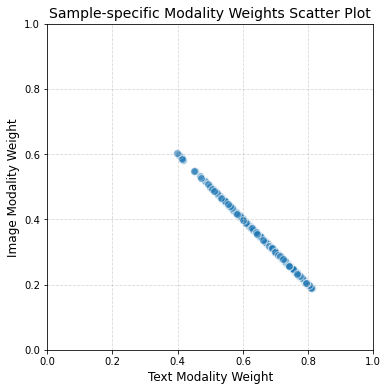

In [3]:
import matplotlib.pyplot as plt

def plot_modality_weights_scatter(weights):
    plt.figure(figsize=(8, 6))
    plt.scatter(weights[:, 0], weights[:, 1], alpha=0.6, edgecolors='w', s=60)
    plt.title("Sample-specific Modality Weights Scatter Plot", fontsize=14)
    plt.xlabel("Text Modality Weight", fontsize=12)
    plt.ylabel("Image Modality Weight", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# plot_modality_weights_scatter(weights)

wx = dynamic_weight_topk_adaptive(train_probs_text, train_probs_image, beta, topk, delta)
plot_modality_weights_scatter(wx)

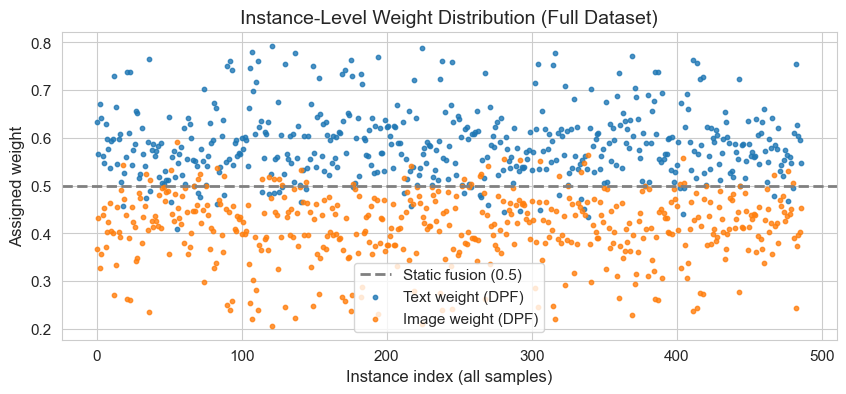

In [18]:
plt.figure(figsize=(10,4))
plt.scatter(np.arange(N), w_text, alpha=0.8, s=10, label='Text weight (DPF)')
plt.scatter(np.arange(N), w_image, alpha=0.8, s=10, label='Image weight (DPF)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=2, label='Static fusion (0.5)')
plt.xlabel('Instance index (all samples)')
plt.ylabel('Assigned weight')
plt.title('Instance-Level Weight Distribution (Full Dataset)')
plt.legend()
plt.show()

In [1]:
"""
Information Energy vs. Shannon Entropy: A Pre-DPF Empirical Analysis
--------------------------------------------------------------------
This script compares two interpretations of modality reliability:
1. Information Energy (Onicescu): higher value = more concentrated = more reliable
2. Shannon Entropy: lower value = more certain = more reliable

The analysis uses validation-set predictive probabilities from MVSA-Single.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.special import entr
import pickle

# ============================================
# Load precomputed validation predictions
# ============================================
with open("cache/dpf_mvsa_single_results.pkl", "rb") as f:
    results = pickle.load(f)

# Validation-set predictive probabilities from ExtraTrees
val_probs_text  = results["val_probs_text"]   # (n_samples, n_classes)
val_probs_image = results["val_probs_image"]  # (n_samples, n_classes)
y_val_int       = results["y_val_int"]        # (n_samples,) ground truth

print(f"Validation set size: {len(y_val_int)} samples")
print(f"Number of classes: {val_probs_text.shape[1]}")

# ============================================
# Compute two interpretation functionals
# ============================================
# Information Energy (Onicescu): higher = more concentrated
ie_text = np.sum(val_probs_text**2, axis=1)
ie_img  = np.sum(val_probs_image**2, axis=1)

# Shannon Entropy: lower = more concentrated (more certain)
ent_text = np.sum(entr(val_probs_text), axis=1)
ent_img  = np.sum(entr(val_probs_image), axis=1)

# ============================================
# Determine the dominant class per modality
# ============================================
pred_text_class = np.argmax(val_probs_text, axis=1)
pred_img_class  = np.argmax(val_probs_image, axis=1)

# Whether each modality's prediction is correct
text_correct = (pred_text_class == y_val_int)
img_correct  = (pred_img_class == y_val_int)

# ============================================
# Core: compare the reliability rankings from IE and Entropy
# ============================================
# IE: higher IE = more concentrated = more reliable
ie_chooses_text = ie_text > ie_img

# Entropy: lower Entropy = more certain = more reliable
ent_chooses_text = ent_text < ent_img

# Agreement rate between the two interpretations
agreement = (ie_chooses_text == ent_chooses_text).mean()
disagreement = 1 - agreement

print("="*60)
print("Information Energy vs. Shannon Entropy: P(x) Analysis")
print("="*60)
print(f"Total validation samples: {len(y_val_int)}")
print(f"Classes: {val_probs_text.shape[1]}")
print()
print("--- Reliability Ranking Comparison ---")
print(f"IE and Entropy agree on which modality is more reliable: {agreement:.2%}")
print(f"Disagreement rate: {disagreement:.2%}")
print()

# ============================================
# Which interpretation aligns more closely with ground truth?
# ============================================
# For each sample: is the modality ranked as more reliable actually correct?
ie_reliable_is_correct = np.where(
    ie_chooses_text,
    text_correct,  # IE chooses text → check if text is correct
    img_correct    # IE chooses image → check if image is correct
)

ent_reliable_is_correct = np.where(
    ent_chooses_text,
    text_correct,  # Entropy chooses text → check if text is correct
    img_correct    # Entropy chooses image → check if image is correct
)

ie_reliable_rate = ie_reliable_is_correct.mean()
ent_reliable_rate = ent_reliable_is_correct.mean()

print("--- Ground Truth Comparison ---")
print(f"IE: modality ranked as more reliable is actually correct in {ie_reliable_rate:.2%}")
print(f"Entropy: modality ranked as more reliable is actually correct in {ent_reliable_rate:.2%}")
print(f"Difference (IE - Entropy): {ie_reliable_rate - ent_reliable_rate:.2%}")
print()

# ============================================
# Spearman correlation between the two functionals
# ============================================
corr_ie_ent_text, _ = spearmanr(ie_text, ent_text)
corr_ie_ent_img, _ = spearmanr(ie_img, ent_img)

print("--- Correlation between IE and Entropy ---")
print(f"Spearman correlation (text modality): {corr_ie_ent_text:.3f}")
print(f"Spearman correlation (image modality): {corr_ie_ent_img:.3f}")
print()

# ============================================
# Summary
# ============================================
print("="*60)
print("SUMMARY")
print("="*60)
if disagreement > 0.10:
    print(f"✓ IE and Entropy disagree in {disagreement:.2%} of samples → interpretations do matter")
else:
    print(f"✗ IE and Entropy almost always agree ({agreement:.2%}) → no practical difference")
    
if abs(ie_reliable_rate - ent_reliable_rate) > 0.03:
    print(f"✓ IE outperforms Entropy by {ie_reliable_rate - ent_reliable_rate:.2%}")
else:
    print(f"✗ IE and Entropy perform similarly ({ie_reliable_rate:.2%} vs {ent_reliable_rate:.2%})")

Validation set size: 487 samples
Number of classes: 3
Information Energy vs. Shannon Entropy: P(x) Analysis
Total validation samples: 487
Classes: 3

--- Reliability Ranking Comparison ---
IE and Entropy agree on which modality is more reliable: 99.18%
Disagreement rate: 0.82%

--- Ground Truth Comparison ---
IE: modality ranked as more reliable is actually correct in 53.80%
Entropy: modality ranked as more reliable is actually correct in 53.80%
Difference (IE - Entropy): 0.00%

--- Correlation between IE and Entropy ---
Spearman correlation (text modality): -0.991
Spearman correlation (image modality): -0.998

SUMMARY
✗ IE and Entropy almost always agree (99.18%) → no practical difference
✗ IE and Entropy perform similarly (53.80% vs 53.80%)


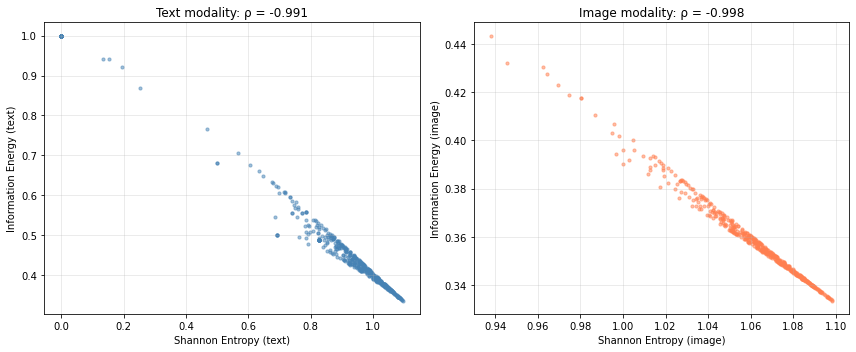

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Text modality
ax1 = axes[0]
ax1.scatter(ent_text, ie_text, alpha=0.5, s=10, c='steelblue')
ax1.set_xlabel('Shannon Entropy (text)')
ax1.set_ylabel('Information Energy (text)')
ax1.set_title(f'Text modality: ρ = {corr_ie_ent_text:.3f}')
ax1.grid(True, alpha=0.3)

# Image modality
ax2 = axes[1]
ax2.scatter(ent_img, ie_img, alpha=0.5, s=10, c='coral')
ax2.set_xlabel('Shannon Entropy (image)')
ax2.set_ylabel('Information Energy (image)')
ax2.set_title(f'Image modality: ρ = {corr_ie_ent_img:.3f}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ie_vs_entropy_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

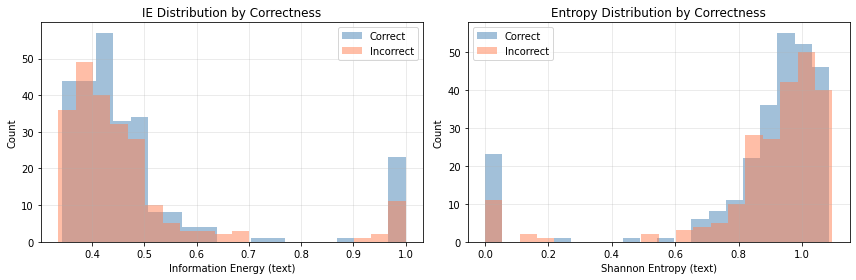

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# IE distribution by correctness
ax1 = axes[0]
for correct, color, label in [(True, 'steelblue', 'Correct'), (False, 'coral', 'Incorrect')]:
    ax1.hist(ie_text[ie_reliable_is_correct == correct], bins=20, alpha=0.5, color=color, label=label)
ax1.set_xlabel('Information Energy (text)')
ax1.set_ylabel('Count')
ax1.set_title('IE Distribution by Correctness')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Entropy distribution by correctness
ax2 = axes[1]
for correct, color, label in [(True, 'steelblue', 'Correct'), (False, 'coral', 'Incorrect')]:
    ax2.hist(ent_text[ent_reliable_is_correct == correct], bins=20, alpha=0.5, color=color, label=label)
ax2.set_xlabel('Shannon Entropy (text)')
ax2.set_ylabel('Count')
ax2.set_title('Entropy Distribution by Correctness')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ie_vs_entropy_correctness.png', dpi=300, bbox_inches='tight')
plt.show()

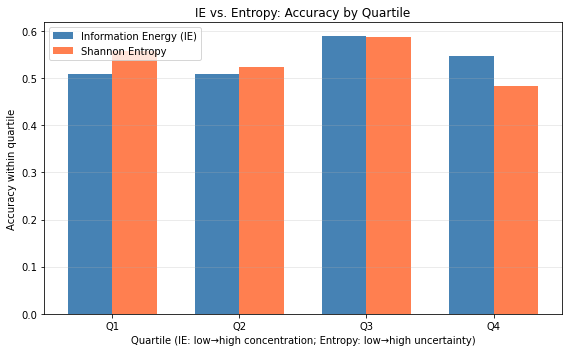

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

# Create quartile groups
df = pd.DataFrame({
    'ie_text': ie_text,
    'ent_text': ent_text,
    'ie_correct': ie_reliable_is_correct,
    'ent_correct': ent_reliable_is_correct
})

df['ie_quartile'] = pd.qcut(df['ie_text'], q=4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
df['ent_quartile'] = pd.qcut(df['ent_text'], q=4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

ie_group_acc = df.groupby('ie_quartile')['ie_correct'].mean()
ent_group_acc = df.groupby('ent_quartile')['ent_correct'].mean()

x = np.arange(4)
width = 0.35
ax.bar(x - width/2, ie_group_acc.values, width, label='Information Energy (IE)', color='steelblue')
ax.bar(x + width/2, ent_group_acc.values, width, label='Shannon Entropy', color='coral')
ax.set_xlabel('Quartile (IE: low→high concentration; Entropy: low→high uncertainty)')
ax.set_ylabel('Accuracy within quartile')
ax.set_title('IE vs. Entropy: Accuracy by Quartile')
ax.set_xticks(x)
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ie_vs_entropy_quartile.png', dpi=300, bbox_inches='tight')
plt.show()